# Phase 3 — Chaos and Predictability: the Lorenz Systems

Before tackling the full fluid models, it is worth meeting **deterministic chaos** in its smallest form. Edward Lorenz's two systems — a three-variable convection caricature and an $N$-variable atmospheric ring — distil the property that makes weather and ocean forecasting hard: a perfectly known, perfectly deterministic system whose trajectories nonetheless become unpredictable because minuscule differences in the initial state grow exponentially {cite}`lorenz1963deterministic,lorenz1996predictability`. somax ships both as first-class models, and they are the standard test-beds for the data-assimilation machinery in [later tutorials](data_assimilation_etkf.ipynb).

**What you will learn**

- How the Lorenz-63 system traces out its butterfly attractor
- What "sensitive dependence on initial conditions" looks like quantitatively
- How the Lorenz-96 ring produces travelling spatiotemporal chaos

## 1. Lorenz-63 — the butterfly attractor

The Lorenz-63 system is three coupled ODEs distilled from Rayleigh–Bénard convection,

```{math}
:label: p3-lorenz63
\begin{aligned}
\dot{x} &= \sigma\,(y - x), \\
\dot{y} &= x\,(\rho - z) - y, \\
\dot{z} &= x\,y - \beta\,z,
\end{aligned}
```

with the classical parameters $(\sigma,\rho,\beta) = (10,\ 28,\ 8/3)$ at which the flow is chaotic {cite}`lorenz1963deterministic`. Trajectories are drawn onto a bounded, fractal **strange attractor** — the two-lobed "butterfly" — never repeating yet never escaping.

In [1]:
import warnings

warnings.filterwarnings("ignore", message=r".*IProgress.*")

import importlib.util
from pathlib import Path

import diffrax as dfx
import jax.numpy as jnp
import matplotlib.pyplot as plt

from somax.models import Lorenz63, Lorenz96, L63State, L96State

In [2]:
try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic("watermark", "-v -m -p numpy,jax,matplotlib,somax")
else:
    print("watermark extension not installed; skipping reproducibility readout.")

watermark extension not installed; skipping reproducibility readout.


In [3]:
IMG_DIR = Path.cwd().parent / "images" / "phase3_chaos"
IMG_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
l63 = Lorenz63.create(sigma=10.0, rho=28.0, beta=8.0 / 3.0)
state0 = L63State(x=jnp.array(1.0), y=jnp.array(1.0), z=jnp.array(1.0))

ts = jnp.arange(0.0, 50.0, 0.01)
sol = l63.integrate(
    state0, t0=0.0, t1=50.0, dt=0.01, saveat=dfx.SaveAt(ts=ts), max_steps=20000
)
print(f"L63 trajectory: {sol.ys.x.shape[0]} samples")

L63 trajectory: 5000 samples


{numref}`p3-attractor-fig` projects the trajectory onto the $(x,z)$ plane, tracing the two wings of the attractor between which the state irregularly switches.

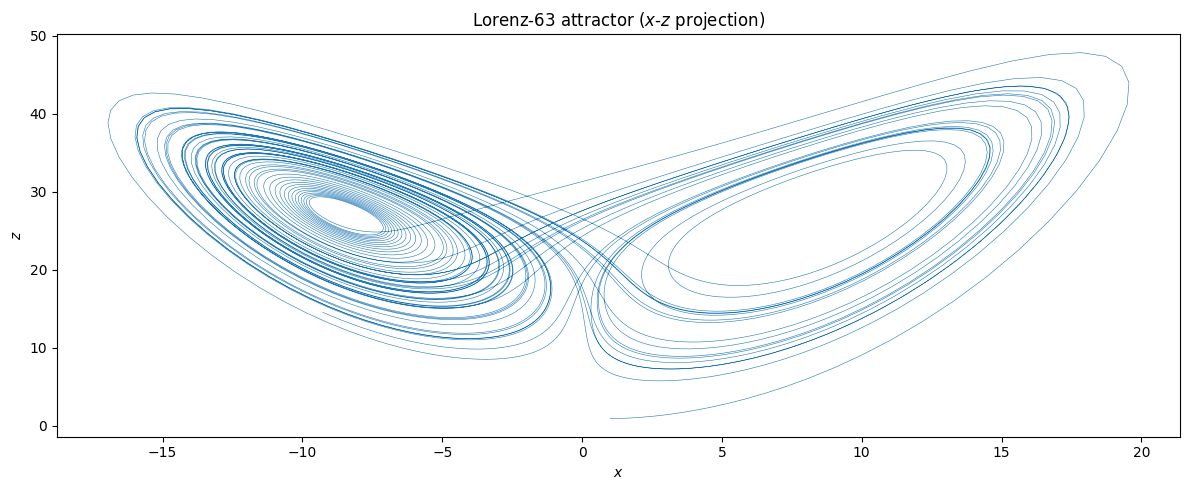

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(sol.ys.x, sol.ys.z, color="C0", lw=0.4)
ax.set(xlabel="$x$", ylabel="$z$", title="Lorenz-63 attractor ($x$-$z$ projection)")
fig.tight_layout()
fig.savefig(IMG_DIR / "l63_attractor.png", dpi=110, bbox_inches="tight")
plt.show()

```{figure} ../images/phase3_chaos/l63_attractor.png
:label: p3-attractor-fig
:width: 90%

The Lorenz-63 strange attractor {eq}`p3-lorenz63`, projected onto the $(x,z)$ plane. The trajectory winds around two lobes, switching between them aperiodically — the signature of low-dimensional chaos.
```

## 2. Sensitive dependence on initial conditions

Chaos is quantified by the exponential separation of nearby trajectories. Two states that start a tiny distance $\delta_0$ apart diverge, on average, as

```{math}
:label: p3-lyapunov
\delta(t) \;\sim\; \delta_0\,e^{\lambda t},
```

where $\lambda > 0$ is the leading **Lyapunov exponent** ($\lambda \approx 0.9$ for Lorenz-63). The finite growth horizon this implies — not any model deficiency — is the fundamental limit on forecast skill {cite}`lorenz1963deterministic`. We integrate two trajectories whose initial conditions differ by $10^{-6}$ and watch the gap. (We use $10^{-6}$ rather than a smaller value because somax runs in single precision by default, where perturbations below $\sim\!10^{-7}$ vanish into round-off.)

In [6]:
pert = 1.0e-6
state_a = L63State(x=jnp.array(1.0), y=jnp.array(1.0), z=jnp.array(1.0))
state_b = L63State(x=jnp.array(1.0 + pert), y=jnp.array(1.0), z=jnp.array(1.0))

ts2 = jnp.arange(0.0, 40.0, 0.01)
sol_a = l63.integrate(
    state_a, t0=0.0, t1=40.0, dt=0.01, saveat=dfx.SaveAt(ts=ts2), max_steps=20000
)
sol_b = l63.integrate(
    state_b, t0=0.0, t1=40.0, dt=0.01, saveat=dfx.SaveAt(ts=ts2), max_steps=20000
)

sep = jnp.sqrt(
    (sol_a.ys.x - sol_b.ys.x) ** 2
    + (sol_a.ys.y - sol_b.ys.y) ** 2
    + (sol_a.ys.z - sol_b.ys.z) ** 2
)
print(f"initial separation {pert:.0e} → final separation {float(sep[-1]):.2f}")

initial separation 1e-06 → final separation 17.68


{numref}`p3-divergence-fig` plots the separation on a log axis. The early near-straight ramp is the exponential growth of {eq}`p3-lyapunov`; its slope is the leading Lyapunov exponent. Growth saturates once the gap reaches the size of the attractor itself — at which point the two forecasts are effectively independent.

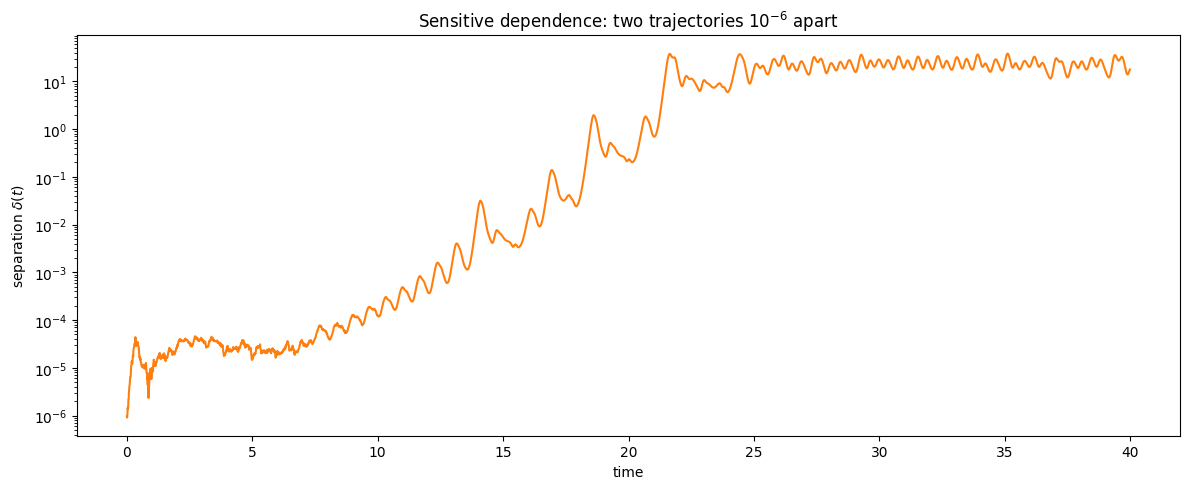

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.semilogy(ts2, sep, color="C1")
ax.set(
    xlabel="time",
    ylabel=r"separation $\delta(t)$",
    title="Sensitive dependence: two trajectories $10^{-6}$ apart",
)
fig.tight_layout()
fig.savefig(IMG_DIR / "l63_divergence.png", dpi=110, bbox_inches="tight")
plt.show()

```{figure} ../images/phase3_chaos/l63_divergence.png
:label: p3-divergence-fig
:width: 90%

Separation between two Lorenz-63 trajectories whose initial states differ by $10^{-6}$. The log-linear ramp is the exponential divergence {eq}`p3-lyapunov`; saturation occurs when the separation reaches the attractor's own scale.
```

## 3. Lorenz-96 — spatiotemporal chaos on a ring

Lorenz-96 extends the idea to $K$ variables arranged on a periodic ring, each representing an atmospheric quantity at one longitude,

```{math}
:label: p3-lorenz96
\dot{x}_k = (x_{k+1} - x_{k-2})\,x_{k-1} - x_k + F,
\qquad k = 1,\dots,K,
```

with cyclic indices and a constant forcing $F$ {cite}`lorenz1996predictability`. The quadratic term advects, the linear term damps, and $F$ injects energy; at $F=8$ the balance produces travelling waves that break into sustained spatiotemporal chaos. Because it is high-dimensional yet cheap, Lorenz-96 is the standard proving ground for data-assimilation schemes.

In [8]:
l96 = Lorenz96.create(F=8.0)
state96 = L96State.init_state(ndim=40, noise=0.01, F=8.0)

ts96 = jnp.arange(0.0, 20.0, 0.01)
sol96 = l96.integrate(
    state96, t0=0.0, t1=20.0, dt=0.01, saveat=dfx.SaveAt(ts=ts96), max_steps=20000
)
hovmoller = sol96.ys.x
print(f"L96 Hovmoller: {hovmoller.shape} (time, longitude)")

L96 Hovmoller: (2000, 40) (time, longitude)


{numref}`p3-hovmoller-fig` is a Hovmöller diagram — longitude on the horizontal axis, time on the vertical — of the 40-variable ring. The slanted bands are westward-propagating waves; their irregular merging and splitting is the spatiotemporal chaos that makes the system a faithful, low-cost atmosphere surrogate.

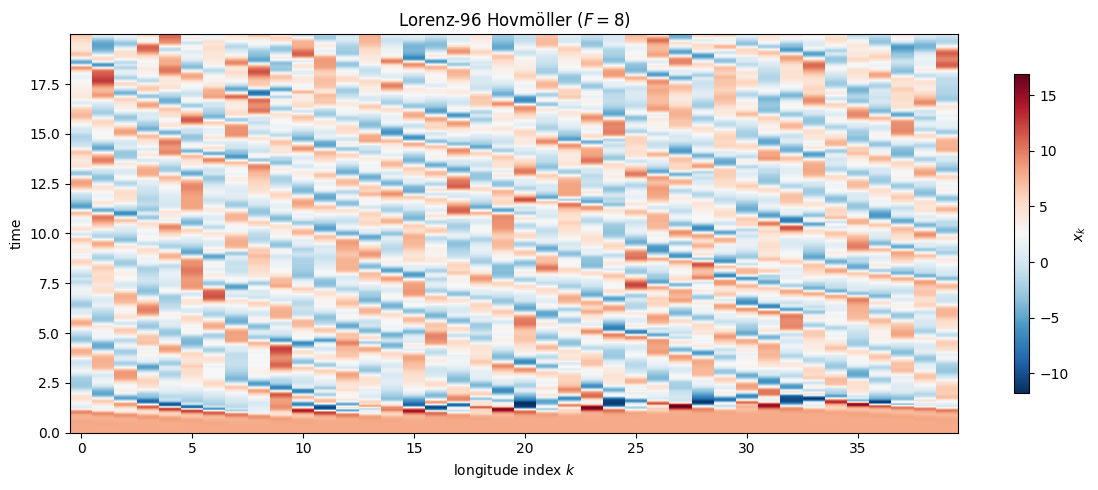

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.pcolormesh(jnp.arange(40), ts96, hovmoller, cmap="RdBu_r", shading="auto")
ax.set(xlabel="longitude index $k$", ylabel="time", title="Lorenz-96 Hovmöller ($F=8$)")
fig.colorbar(im, ax=ax, shrink=0.8, label="$x_k$")
fig.tight_layout()
fig.savefig(IMG_DIR / "l96_hovmoller.png", dpi=110, bbox_inches="tight")
plt.show()

```{figure} ../images/phase3_chaos/l96_hovmoller.png
:label: p3-hovmoller-fig
:width: 90%

Hovmöller diagram of the Lorenz-96 ring {eq}`p3-lorenz96` at $F=8$. Slanted stripes are propagating waves; their continual reorganisation is sustained spatiotemporal chaos.
```

## Summary

- Lorenz-63 {eq}`p3-lorenz63` traces a bounded **strange attractor**; the flow is deterministic yet never repeats.
- **Sensitive dependence** — exponential separation {eq}`p3-lyapunov` of nearby states at the positive Lyapunov rate — is the intrinsic limit on predictability, not a numerical artifact.
- Lorenz-96 {eq}`p3-lorenz96` lifts chaos onto a ring, giving high-dimensional spatiotemporal chaos at trivial cost — the canonical data-assimilation test-bed used in the [ETKF](data_assimilation_etkf.ipynb) and [4DVar](data_assimilation_4dvar.ipynb) tutorials.

The [final chapter](phase4_gfd.ipynb) brings the staggered grids, operators, and elliptic solvers of Phases 0–2 together into the geophysical shallow-water and quasi-geostrophic models.